In [1]:
import time
import numpy as np
from examples.seismic import SeismicModel, AcquisitionGeometry, Receiver
from examples.seismic.acoustic import AcousticWaveSolver
from examples.seismic.datasets import SeismogramDataset, VelocityModel
from devito import info, TimeFunction, Function, Eq, Operator, norm, inner
from examples.seismic.utils import taper_wavelet, estimate_centroid_frequency_gather
from devito import configuration
from matplotlib import pyplot as plt


PATH_MODEL = "../data/South_ForMigr_2.dat"
PATH_DATA = "../data/21-20.sgy"
NBL=500
SO=4
TMAX = 40.0

configuration["platform"] = "nvidiaX"
configuration["language"] = "openacc"
configuration["compiler"] = "nvc"

def setup_model_and_geometry(iter_num):
    """Set up the velocity model and acquisition geometry"""
    dataset = SeismogramDataset(PATH_DATA, "sou", invert_elevs=True)
    xmin, xmax = min(dataset.x_coords.min(), dataset.opposite_x.min()), max(dataset.x_coords.max(), dataset.opposite_x.max())
    spacing = (0.025, 0.025)
    velmodel = VelocityModel(
        PATH_MODEL,
        dx=spacing[0],
        dz=spacing[1],
        clip=True,
        xmin=xmin - 3,
        xmax=xmax + 3,
        zmin=-318,
    )
    velmodel.pad_left(4 + 2)
    velmodel.pad_right(8 * int(0.5 / spacing[0]) + 2)
    velmodel.pad_bottom(10 * int(0.5 / spacing[0]) + 2)
    velmodel.pad_top(7 * int(0.5 / spacing[0]))

    vp = velmodel.vp.T
    origin = velmodel.x[0], velmodel.z[0]
    model = SeismicModel(
        vp=vp,
        origin=origin,
        shape=vp.shape,
        spacing=spacing,
        space_order=SO,
        nbl=NBL,
        bcs="damp",
        fs=False,
    )
    return model, dataset

In [2]:
model, dataset = setup_model_and_geometry(0)
dataset._dt_r = model.critical_dt
dataset._t_max_r = TMAX
dataset.resample_on()

Operator `initdamp` ran in 0.16 s


In [3]:
print(model.critical_dt)

0.003084


In [3]:
d_obs, sx, sz, rec_x, rec_z = dataset[20]

t0 = 0
tn = TMAX

src_pos = np.array([sx, sz])[None, :]
rec_pos = np.vstack([rec_x, rec_z]).T
geometry = AcquisitionGeometry(
    model, rec_pos, src_pos,
    t0, tn, f0=0.25, src_type='Ricker'
)
solver = AcousticWaveSolver(model, geometry, space_order=SO)
d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                     coordinates=geometry.rec_positions)
solver.forward(vp=model.vp, save=False, rec=d_syn)
residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                coordinates=geometry.rec_positions)
residual.data[:] = d_syn.data[:] - d_obs.T
srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

Operator `Forward` ran in 4.04 s
No source type defined, returning uninitialized (zero) source
No source type defined, returning uninitialized (zero) source
Operator `Adjoint` ran in 4.04 s


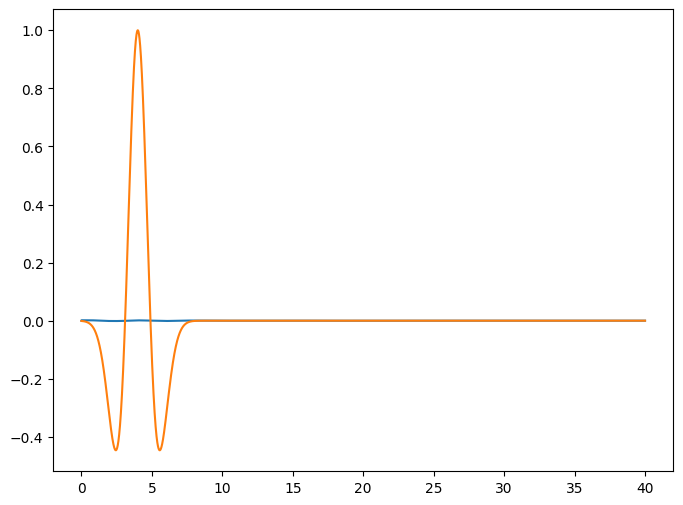

In [4]:
plt.plot(geometry.time_axis.time_values, srca.data[:])
plt.plot(geometry.time_axis.time_values, geometry.src.data[:])
plt.show()

In [5]:
def calculate_step_size(misfit, h):
    # Compute numerator and denominator for step size
    numerator = np.dot(misfit.reshape(-1), h.reshape(-1))
    denominator = np.dot(h.reshape(-1), h.reshape(-1))
    return numerator / denominator

from scipy.signal.windows import tukey

def left_taper_tukey(signal, alpha=0.5):
    """
    Taper the left side of a signal using a Tukey window.
    
    Args:
        signal (np.ndarray): Input signal (gradient).
        alpha (float): Shape parameter of the Tukey window (0=rectangular, 1=Hann).
    
    Returns:
        np.ndarray: Tapered signal.
    """
    n = len(signal)
    window = tukey(n * 2, alpha=alpha)[:n]  # Take left half of symmetric window
    return signal * window, window

In [ ]:
from devito.logger import set_log_noperf
set_log_noperf()

ImportError: cannot import name 'disable_perf_logs' from 'devito.logger' (/home/andrey/devito-vti/devito/logger.py)

In [ ]:
max_iter = 5
for k in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[k]
    f0 = estimate_centroid_frequency_gather(d_obs.T, model.critical_dt) / 1e3

    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=f0 * 2, src_type='Gabor'
    )
    current_wavelet = geometry.src.data[:].reshape(-1)
    initial_wavelet = np.copy(current_wavelet)
    scale_factor = 1.
    for i in range(max_iter):
        # Forward modeling
        geometry = AcquisitionGeometry(
            model, rec_pos, src_pos,
            t0, tn, f0=0.25, src_type=None, wav_data=current_wavelet
        )
        solver = AcousticWaveSolver(model, geometry, space_order=SO)
        d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
        solver.forward(vp=model.vp, rec=d_syn, save=False)
        residual = Receiver(name='residual', grid=model.grid, time_range=geometry.time_axis,
                    coordinates=geometry.rec_positions)
        # if i == 0:
        scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
        print("Scale: ", scale_factor)
            # d_obs /= scale_factor

        print(np.quantile(d_obs, 0.99))
        print(scale_factor*np.quantile(np.array(d_syn.data[:]), 0.99))
        residual.data[:] = scale_factor*d_syn.data - d_obs.T
        
        # Compute gradient (adjoint source)
        srca, _, _ = solver.adjoint(vp=model.vp, rec=residual)
        gradient = srca.data
        gradient_tapered, window = left_taper_tukey(gradient.reshape(-1), alpha=0.05)
        beta = 0.001
        gradient_tapered += beta*(current_wavelet - initial_wavelet)
        misfit = geometry.src.data.reshape(-1) - gradient_tapered.reshape(-1)
        alpha = 0.5*calculate_step_size(misfit, gradient)
        print(alpha)
        # Update wavelet
        current_wavelet = current_wavelet - alpha * gradient_tapered
        print(f"Iter {i}: Misfit = {np.dot(misfit.reshape(-1), misfit.reshape(-1))**2:.4e}")
    plt.plot(geometry.time_axis.time_values, current_wavelet/np.max(np.abs(current_wavelet)))
    plt.plot(geometry.time_axis.time_values, initial_wavelet/np.max(np.abs(initial_wavelet)))
    plt.show()
    np.save(f"Mex_wavelet_{k}_norm.npy", current_wavelet)
    np.save(f"Mex_wavelet_scale_{k}.npy", scale_factor)

In [11]:
d_syn.data[:].min()

Data(-1.6923479e-05, dtype=float32)

Operator `Forward` ran in 4.04 s


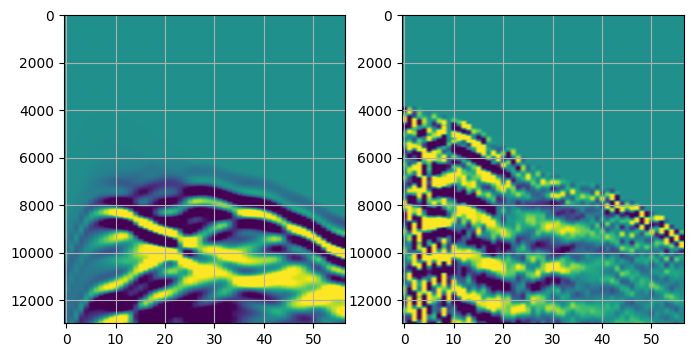

Operator `Forward` ran in 4.04 s


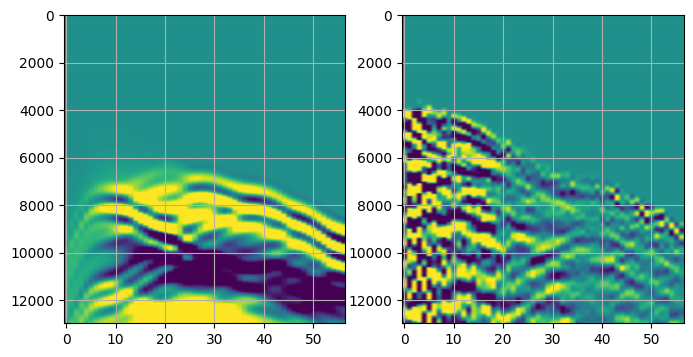

Operator `Forward` ran in 4.04 s


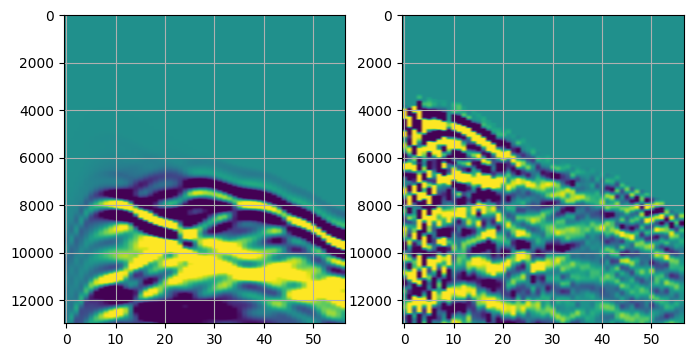

Operator `Forward` ran in 4.04 s


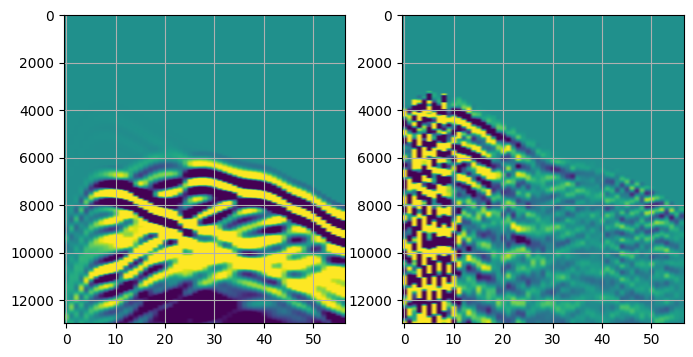

In [ ]:
N = 40
t0 = 0
tn = TMAX
for i in range(len(dataset)):
    d_obs, sx, sz, rec_x, rec_z = dataset[i]
    wav_data = np.load(f"Mex_wavelet_{i}_norm.npy")
    src_pos = np.array([sx, sz])[None, :]
    rec_pos = np.vstack([rec_x, rec_z]).T
    geometry = AcquisitionGeometry(
        model, rec_pos, src_pos,
        t0, tn, f0=0.25, src_type=None, wav_data=wav_data
    )
    solver = AcousticWaveSolver(model, geometry, space_order=SO)
    d_syn = Receiver(name='d_syn', grid=model.grid, time_range=geometry.time_axis,
                        coordinates=geometry.rec_positions)
    solver.forward(vp=model.vp, save=False, rec=d_syn)
    scale_factor = np.linalg.norm(d_obs.ravel())/np.linalg.norm(np.array(d_syn.data[:]).ravel())
    np.save(f"Mex_wavelet_{i}_norm_scalar.npy", scale_factor)
    
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    qa = np.quantile(d_obs, 0.95)
    axs[0].imshow(scale_factor*d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
    axs[0].grid()
    axs[1].imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
    axs[1].grid()
    plt.show()
# srca, v, summary = solver.adjoint(vp=model.vp, rec=residual)

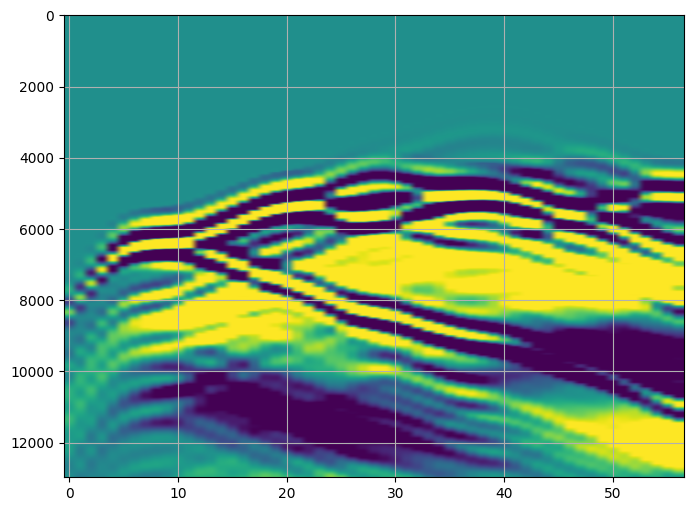

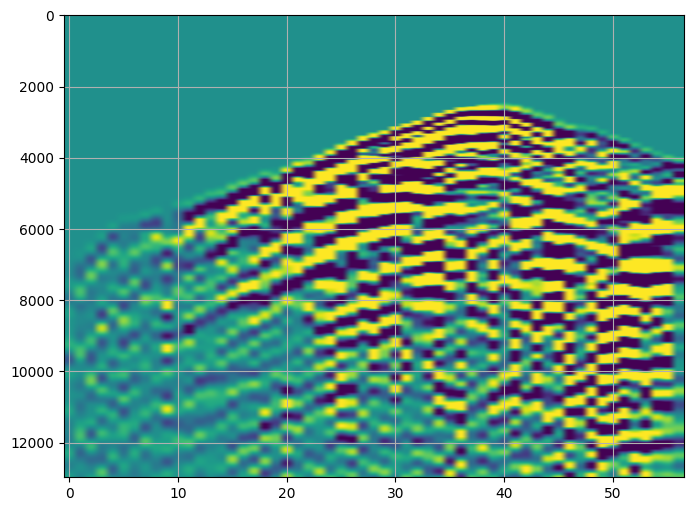

In [12]:
from matplotlib import pyplot as plt
# d_obs, sx, sz, rec_x, rec_z = dataset[20]
qa = np.quantile(d_obs, 0.9)
# qa = np.quantile(np.array(d_syn.data[:]).ravel(), 0.99)
plt.imshow(d_syn.data[:], aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()
plt.imshow(d_obs.T, aspect='auto', vmin=-qa, vmax=qa)
plt.grid()
plt.show()